# Machine learning techniques for intrusion detection
## Introduzione
L'obbiettivo di questo notebook è applicare tecniche di machine learning al dataset NLS-KDD, contenente informazioni sul flusso di traffico di rete verso una infrastruttura IT, al fine di confrontare le prestazioni di diversi modelli nel classificare traffico come 'normale' o 'malevolo'.

In particolare verranno presi in considerazione quattro modelli di ML:
*   Logistic regression
*   Random forest
*   Multi-layer perceptron (MLP)
*   AdaBoost









## Imports

In [ ]:
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
import seaborn as sns

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

#feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import VarianceThreshold

# to evaluate models
from sklearn.model_selection import cross_val_predict, cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import loguniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



## Un primo sguardo al dataset


In [ ]:
df = pd.read_csv('/KDDTrainClean.csv')
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

Il dataset è formato 42 colonne, 41  features di cui 3 categoriche mentre tutte le altre numeriche. Vediamo che valori assumono:

In [ ]:
for column in df.columns:
      print(df[column].value_counts())
      print("=============================")

duration
0        115955
1          1989
2           843
3           557
4           351
          ...  
4946          1
5284          1
20771         1
3294          1
679           1
Name: count, Length: 2981, dtype: int64
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64
src_bytes
0        49392
8         3691
1         2432
44        2334
45        2089
         ...  
1940         1
12973        1
1899         1
1661         1
2358         1
Name: count, Length: 3341, dtype: int64
dst_bytes
0  

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


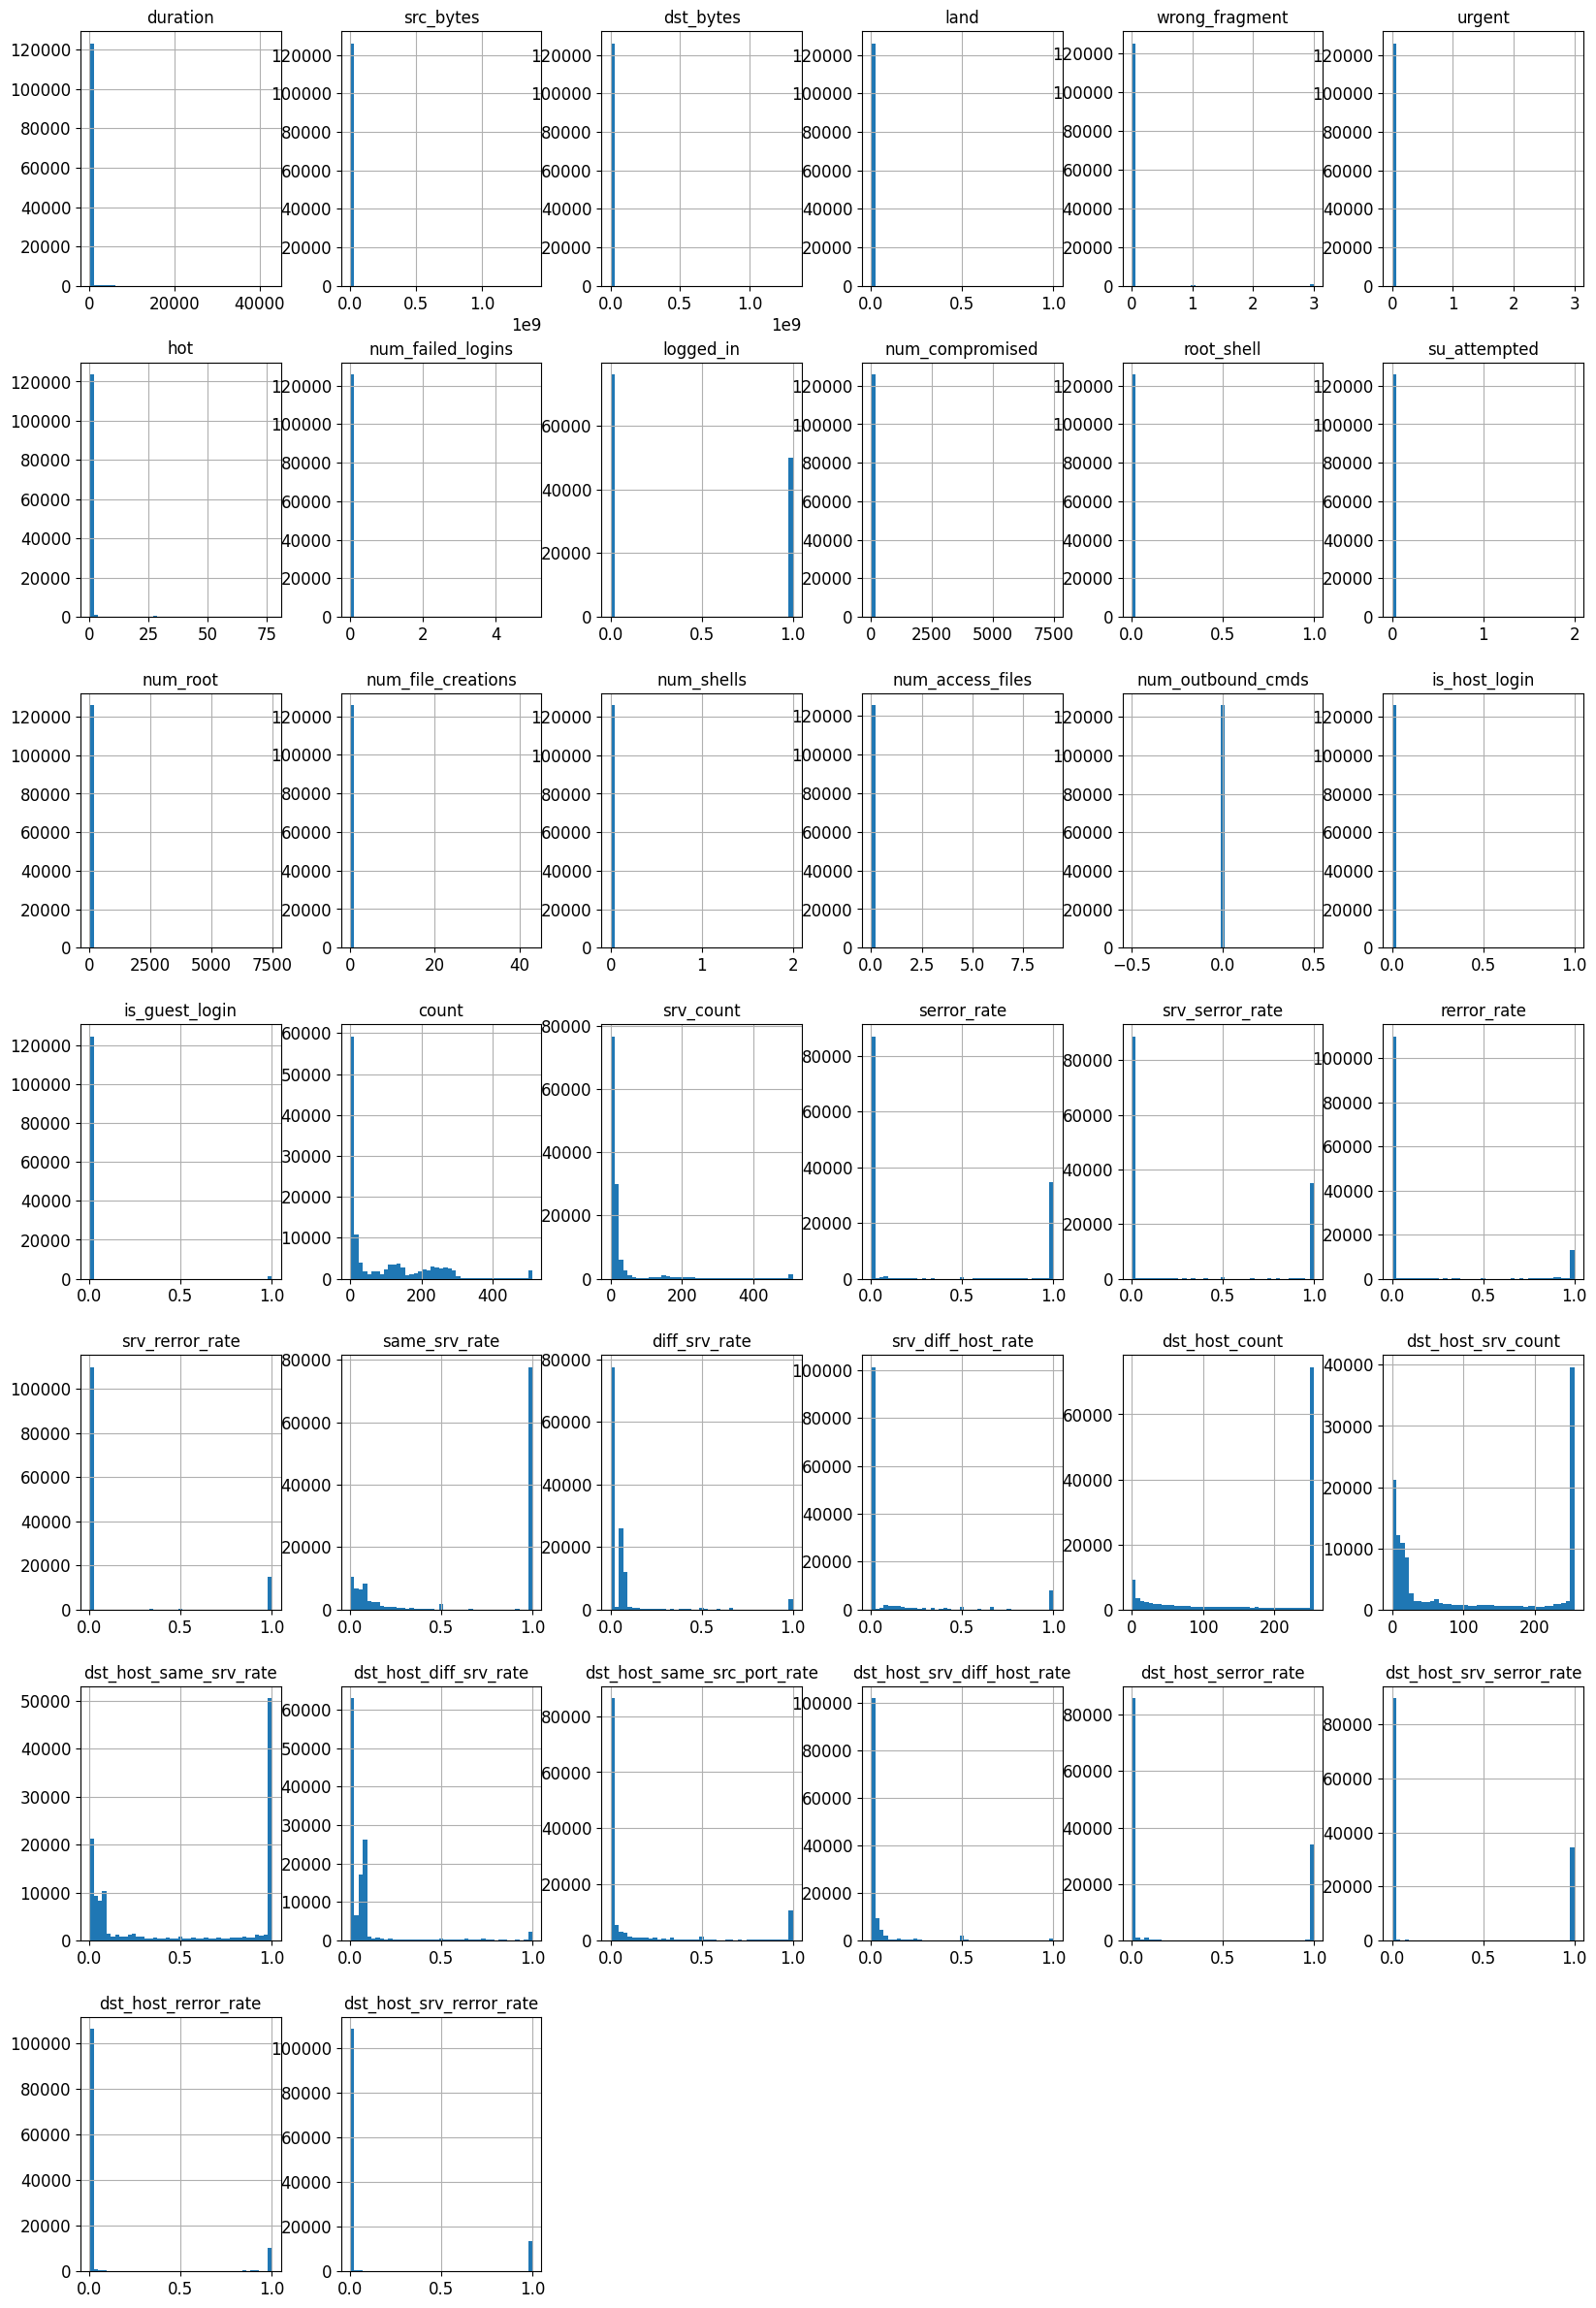

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=43, figsize=(20,30))
plt.show()

Il dataset risulta sparso dato che tutte le features assumono per la maggior parte degli esempi il valore 0. \\
Ad un primo sguardo le feature che risultano essere più sparse sono:
* root_shell
* num_shells
* num_outbound_cmds
* is_guest_login
* is_host_login
* urgent
* su_attempted
* land
[//]: # (Hello)
in particolare la feature "num_outbound_cmds" risulta avere tutti esempi uguali a 0 e quindi andrà eliminata.



## Divisione del dataset in training e test set
Prima di dividere il dataset, dato che si tratta di un task di classificazione binaria, modifico la colonna target in modo che abbia label "attack" in tutti i casi in cui il traffico non sia etichettato come "normal".

Inoltre elimino la feature "num_outbound_cmds".

In [ ]:
df.drop('num_outbound_cmds', axis=1, inplace=True)
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


Ora divido il dataset in training e test set, in modo da mettere da parte quest'ultimo e procedere con la visualizzazione del solo training set.

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
95141,0,tcp,http,SF,214,14939,0,0,0,0,...,255,1.00,0.00,0.02,0.06,0.0,0.0,0.0,0.0,normal
37486,0,tcp,private,S0,0,0,0,0,0,0,...,2,0.01,0.06,0.00,0.00,1.0,1.0,0.0,0.0,attack
34926,0,tcp,http,REJ,0,0,0,0,0,0,...,8,0.03,0.06,0.00,0.00,0.0,0.0,1.0,1.0,attack
34589,0,tcp,http,SF,257,259,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,normal
11420,0,udp,other,SF,516,4,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,normal


## Visualizzazione del training set

In [ ]:
df=train_set.copy()

### Distribuzione della classe target
Ora verifico la distribuzione dei due valori "normal" e "attack" che può assumere la classe target

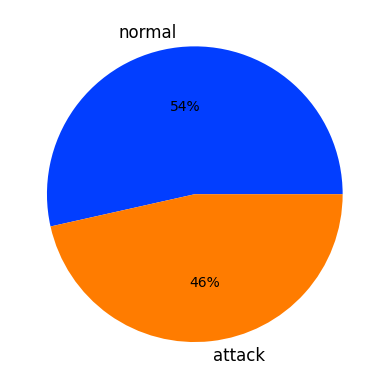

In [ ]:
labels = df['label'].value_counts()
palette_color = sns.color_palette('bright')
plt.pie(labels.values, labels=labels.index, colors=palette_color, autopct='%.0f%%')
plt.show()

I due valori che può assumere il target non risultano sbilanciati, quindi non ci sarà bisogno di applicare tecniche di oversampling o undersampling in modo da evitare overfitting.

### Distribuzione delle feature categoriche

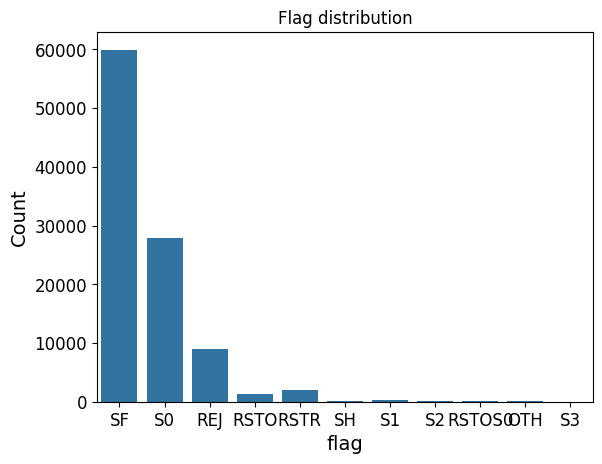

In [ ]:
sns.countplot(x='flag', data=df)
plt.title('Flag distribution')
plt.xlabel('flag')
plt.ylabel('Count')
plt.show()


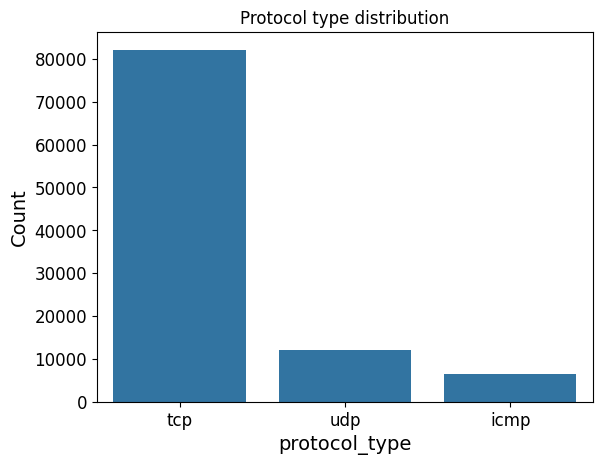

In [ ]:
sns.countplot(x='protocol_type', data=df)
plt.title('Protocol type distribution')
plt.xlabel('protocol_type')
plt.ylabel('Count')
plt.show()


<ipython-input-73-6a0bd370a699>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


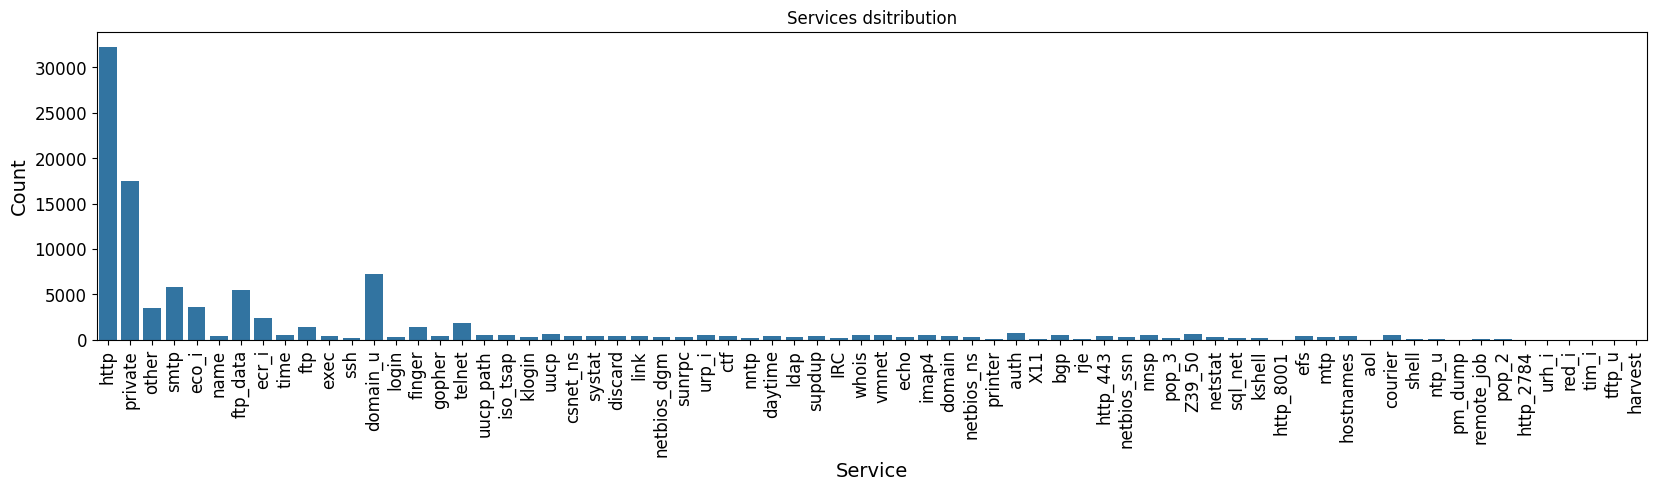

In [ ]:
plt.figure(figsize=(20, 4))
ax= sns.countplot(x='service', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Services dsitribution')
plt.xlabel('Service')
plt.ylabel('Count')
plt.show()

### Combinazioni

#### Flag

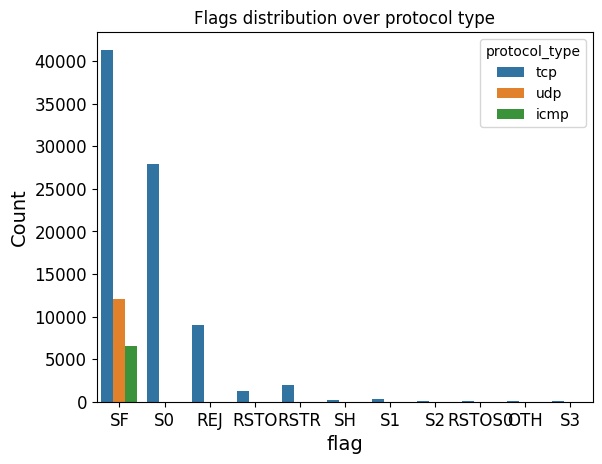

In [ ]:
sns.countplot(x='flag', data=df, hue='protocol_type')
plt.title('Flags distribution over protocol type')
plt.xlabel('flag')
plt.ylabel('Count')
plt.show()

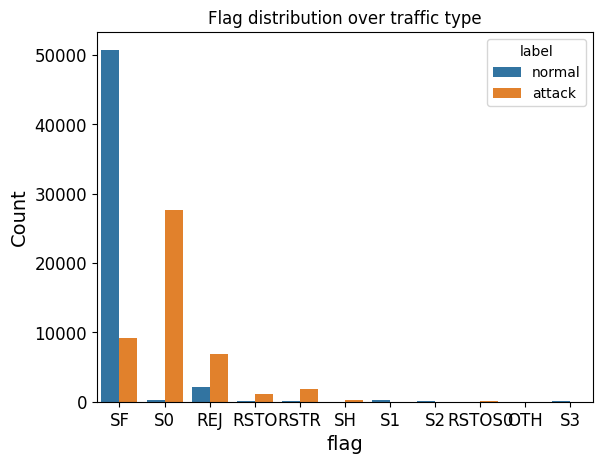

In [ ]:
sns.countplot(x='flag', data=df, hue='label')
plt.title('Flag distribution over traffic type')
plt.xlabel('flag')
plt.ylabel('Count')
plt.show()

Da questi grafici si può capire che SF è il flag di una connessione (hansdshake) andata a buon fine e che è comune a tutti e 3 i tipi di protocollo presenti nel dataset. \\
Il flag S0 è solo un flag di TCP che indica la mancata ricezione del SYN message, per cui tracce con questo flag probabilmente fanno parte di un attacco DoS. \\
In questo caso di classificazione binaria l'importanza maggiore l'avranno i primi 3/4 valori, dato che rappresentano la maggior parte degli esempi di traffico malevolo e non malevolo.

#### Distribuzione degli attacchi rispetto i 3 tipi di protocolli nel dataset

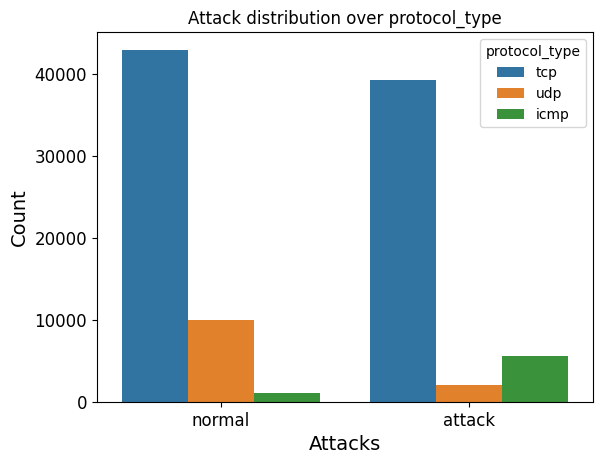

In [ ]:
sns.countplot(x='label', data=df, hue='protocol_type')
plt.title('Attack distribution over protocol_type')
plt.xlabel('Attacks')
plt.ylabel('Count')
plt.show()

#### Services

<ipython-input-77-89c02fc4ba7c>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


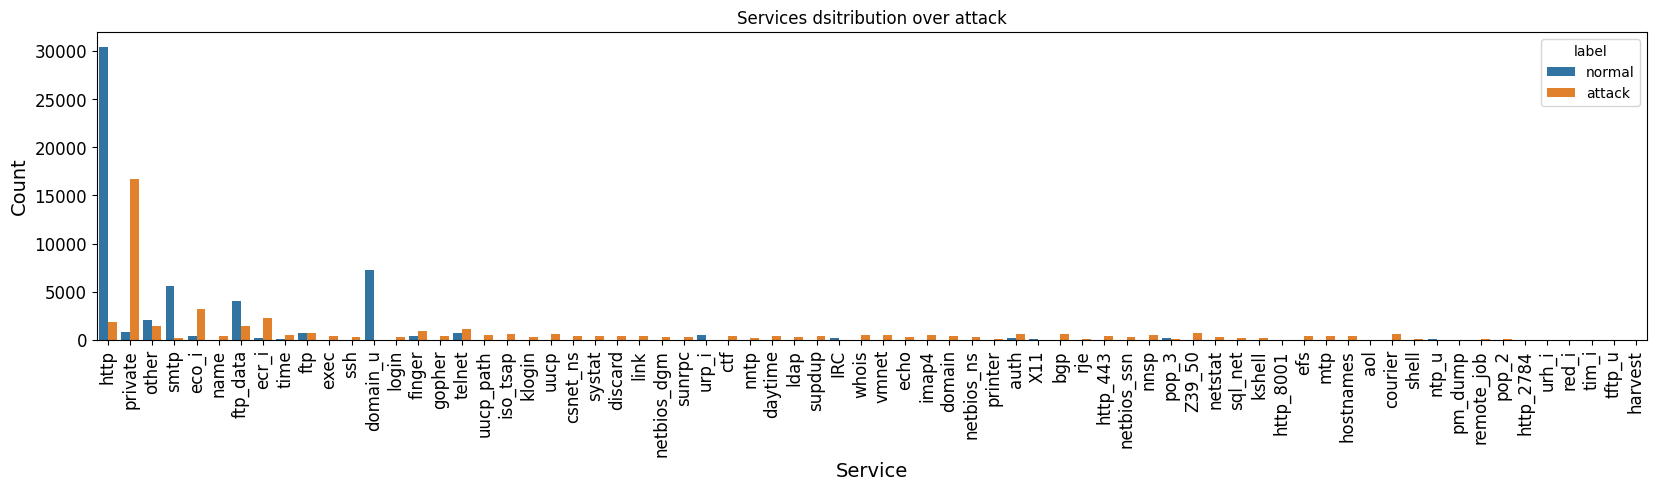

In [ ]:
plt.figure(figsize=(20, 4))
ax= sns.countplot(x='service', data=df, hue='label')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Services dsitribution over attack')
plt.xlabel('Service')
plt.ylabel('Count')
plt.show()

Analogamente ai flag, posso dire che i tipi di servizio più significativi per la classificazione binaria saranno i primi 10 più 'domain_u', per la stessa ragione: contengono la maggior parte delle occorrenze di traffico malevolo e non malevolo.

#### Attack distribution over login

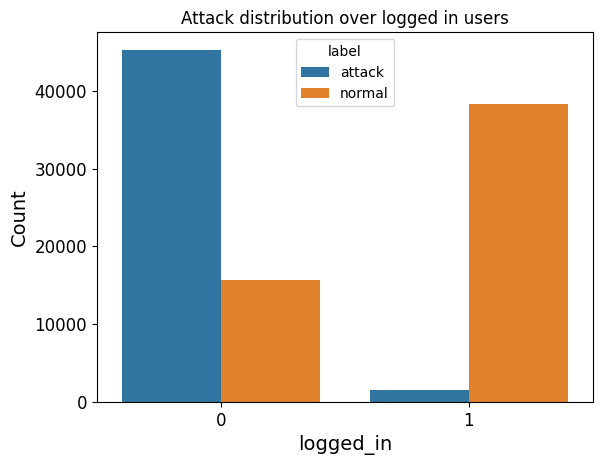

In [ ]:
sns.countplot(x='logged_in', data=df, hue='label')
plt.title('Attack distribution over logged in users')
plt.xlabel('logged_in')
plt.ylabel('Count')
plt.show()

## Pre-processamento
In questa parte controllo che non ci siano valori mancanti nel training set, effettuo l'encoding delle classi categoriche, elimino le features numeriche aventi bassa varianza e infine normalizzo il training set. \\
Prima di effettuare queste operazioni separo la colonna target e la trasformo in modo che sia binaria.

In [ ]:
y_train = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
X_train = df.drop('label', axis=1)
y_train.head()

,label
95141,0
37486,1
34926,1
34589,0
11420,0


### Verifica della presenza di valori mancanti nel training set

In [ ]:
X_train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
cat_columns = X_train.select_dtypes(exclude=[np.number]).columns
binary_columns= ['land', 'logged_in','root_shell', 'is_host_login', 'is_guest_login']
num_columns= [col for col in X_train.columns if col not in cat_columns and col not in binary_columns]
print("feature categoriche:",cat_columns)
print("feature numeriche:",num_columns)
print("feature binarie:",binary_columns)

feature categoriche: Index(['protocol_type', 'service', 'flag'], dtype='object')
feature numeriche: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
feature binarie: ['land', 'logged_in', 'root_shell', 'is_host_login', 'is_guest_login']


### Encoding delle features categoriche
Procedo con il one-hot encoding delle tre variabili categoriche ["protocol_type", "flag", "service" ]. In output avrò tante features binarie quanti valori può assumere la feature di partenza.

In [ ]:
def encode_categorical_columns(X_train, cat_columns):
  encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
  encoded_array = encoder.fit_transform(X_train.get(cat_columns))
  encoded_X = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(), index=X_train.index)
  X_train_encoded= pd.concat([X_train, encoded_X], axis='columns')
  X_train_encoded.drop(cat_columns, axis=1, inplace=True)
  return X_train_encoded

In [ ]:
X_train_encoded = encode_categorical_columns(X_train, cat_columns)
print(f"Il dataset orginale aveva:",X_train.shape[1],"features\n")
print(f"Il dataset one-hot encoded ha:",X_train_encoded.shape[1],"features\n")

Il dataset orginale aveva: 40 features

Il dataset one-hot encoded ha: 121 features



### Eliminazione feature con bassa varianza
In questa parte faccio una prima scrematura delle features, eliminando quelle con varianza minore di 0.01.

In realtà anche se una feature ha bassa varianza potrebbe comunque essere informativa in quanto potrebbe rappresentare un pattern particolare nel dataset, in questo caso un tipo particolare di attacco.

Dato però che il task è di classificazione binaria e quindi non ho bisogno di una granularità fine nel riconoscere i diversi tipi di attacco, procederò in questo modo.

In [ ]:
threshold = 0.01
columns_to_select=num_columns+binary_columns
selector = VarianceThreshold(threshold)
selector.fit(X_train_encoded[columns_to_select])
features_to_remove = [x for x in X_train.get(columns_to_select) if x not in selector.get_feature_names_out()]
print("Features removed:",features_to_remove)
X_train_encoded = X_train_encoded.drop(features_to_remove, axis=1)

Features removed: ['urgent', 'num_failed_logins', 'su_attempted', 'num_shells', 'land', 'root_shell', 'is_host_login', 'is_guest_login']


In [ ]:
num_columns= list(set(num_columns) - set(features_to_remove))
binary_columns= list(set(binary_columns) - set(features_to_remove))
print("feature numeriche:",num_columns)
print("feature binarie:",binary_columns)

feature numeriche: ['dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'srv_count', 'dst_host_srv_count', 'dst_host_same_src_port_rate', 'dst_host_diff_srv_rate', 'wrong_fragment', 'srv_rerror_rate', 'rerror_rate', 'dst_host_serror_rate', 'srv_diff_host_rate', 'src_bytes', 'same_srv_rate', 'num_access_files', 'dst_bytes', 'num_root', 'serror_rate', 'count', 'srv_serror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_same_srv_rate', 'dst_host_count', 'duration', 'diff_srv_rate', 'dst_host_rerror_rate', 'hot', 'num_file_creations', 'num_compromised']
feature binarie: ['logged_in']


### Normalizzazione del training set
Normalizzo le feature numeriche nel training set in modo che tutte le features abbiano una scala consistente tra loro. Così il learning dei modelli non verrà influenzato dalle feature che assumono valori più grandi ma considererà equamente tutte le features.

In [ ]:
print("feature che verranno normalizzate:", num_columns)
X_train_num_scaled = StandardScaler().fit_transform(X_train_encoded[num_columns])
X_train_cat_scaled = X_train_encoded[[col for col in X_train_encoded.columns if col not in num_columns]].to_numpy()
X_train_scaled= np.concatenate((X_train_num_scaled, X_train_cat_scaled), axis=1)

feature che verranno normalizzate: ['dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'srv_count', 'dst_host_srv_count', 'dst_host_same_src_port_rate', 'dst_host_diff_srv_rate', 'wrong_fragment', 'srv_rerror_rate', 'rerror_rate', 'dst_host_serror_rate', 'srv_diff_host_rate', 'src_bytes', 'same_srv_rate', 'num_access_files', 'dst_bytes', 'num_root', 'serror_rate', 'count', 'srv_serror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_same_srv_rate', 'dst_host_count', 'duration', 'diff_srv_rate', 'dst_host_rerror_rate', 'hot', 'num_file_creations', 'num_compromised']


## Scelta delle metriche
Dato che vorrei che i modelli evitassero di etichettare tracce di traffico malevolo come traffico normale (vorrei quindi minimizzare i falsi negativi), la metrica più importante da prendere in considerazione è la **recall**. \
Infatti quest'ultima misura quante delle istanze etichettate come vere nel dataset vengano effetivamente predette come vere dal classificatore.\
Viene definita come:
$$ \frac{TP}{TP+FN}$$
Oltre alla recall, che rimane la metrica principale e che verrà quindi usata successivamente per valutare gli iperparametri dei modelli, considero anche la **precision** che è definita come:
$$\frac{TP}{TP+FP}$$
cioè in questo caso quanto il traffico etichettato come malevolo lo sia effettivamente.


Misurerò anche **f1 score** che unisce precision e recall essendone la media armonica.
Infine, dato che la classe target non risulta essere sbilanciata, prenderò in considerazione anche l'**accuracy**.

## Feature selection


### Filter method
Questo metodo seleziona le feature indipendentemente da qualsiasi modello, basandosi sulla loro *rilevanza* rispetto alla classe target. \
La *rilevanza* verrà misurata dal valore della **mutua informazione** tra ogni feature e la classe target. La mutua informazione non è altro che l'information gain, essendo definita come:
$$ I(X,Y) = H(X)-H(X|Y)$$
L'informazione che conoscere $Y$ (la feature che sto esaminando), mi da su $X$ (la classe target) equivale alla differenza tra l'entropia di $X$ e l'entropia condizionale di $X$ dato $Y$; cioè quanto conoscere $Y$ diminuisca l'entropia ( l'incertezza) di $X$

In [ ]:
pd.set_option('display.max_rows', None)
mutual_info = mutual_info_classif(X_train_scaled, y_train)
mutual_info_df = pd.DataFrame({"Features": X_train_encoded.columns, "mi_scores":mutual_info})
mutual_info_df=mutual_info_df.sort_values(by="mi_scores",ascending=False)
print(mutual_info_df)

                        Features  mi_scores
11                     srv_count   0.565327
14                   rerror_rate   0.439989
23   dst_host_same_src_port_rate   0.362902
12                   serror_rate   0.359340
111                      flag_SF   0.339142
3                 wrong_fragment   0.332748
20            dst_host_srv_count   0.309498
28      dst_host_srv_rerror_rate   0.290972
9               num_access_files   0.290864
5                      logged_in   0.287603
0                       duration   0.282463
16                 same_srv_rate   0.280617
18            srv_diff_host_rate   0.272570
17                 diff_srv_rate   0.265313
107                      flag_S0   0.260448
19                dst_host_count   0.190864
56                  service_http   0.189630
21        dst_host_same_srv_rate   0.141773
4                            hot   0.134060
81               service_private   0.119027
10                         count   0.101436
1                      src_bytes

Dopo aver ottenuto i valori di mutual info per tutte le feature grafico il risultato per scegliere quante feature selezionare.

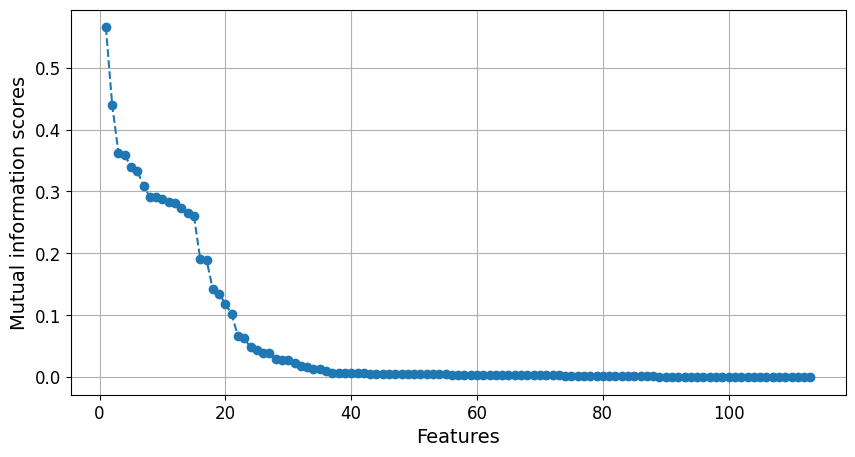

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mutual_info_df)+1), mutual_info_df["mi_scores"], marker='o', linestyle='--')
plt.xlabel('Features')
plt.ylabel('Mutual information scores')
plt.grid()
plt.show()

In [ ]:
best_num_features = 40
selector= SelectKBest(mutual_info_classif, k=best_num_features)
selected_features_skb=mutual_info_df['Features'].iloc[: best_num_features+1]
print("Selected features:\n", selected_features_skb )
print("Dropped features: \n", mutual_info_df['Features'].iloc[best_num_features+1:])

Selected features:
 11                       srv_count
14                     rerror_rate
23     dst_host_same_src_port_rate
12                     serror_rate
111                        flag_SF
3                   wrong_fragment
20              dst_host_srv_count
28        dst_host_srv_rerror_rate
9                 num_access_files
5                        logged_in
0                         duration
16                   same_srv_rate
18              srv_diff_host_rate
17                   diff_srv_rate
107                        flag_S0
19                  dst_host_count
56                    service_http
21          dst_host_same_srv_rate
4                              hot
81                 service_private
10                           count
1                        src_bytes
2                        dst_bytes
44                service_domain_u
8               num_file_creations
7                         num_root
24     dst_host_srv_diff_host_rate
22          dst_host_diff_srv_rate


Rimetto il valore delle variabili delle colonne al loro valore originale dato che d'ora in poi utilizzerò solo 'X_train' come dataset.

In [ ]:
cat_columns = X_train.select_dtypes(exclude=[np.number]).columns
binary_columns= ['land', 'logged_in','root_shell', 'is_host_login', 'is_guest_login']
num_columns= [col for col in X_train.columns if col not in cat_columns and col not in binary_columns]
print("feature categoriche:",cat_columns)
print("feature numeriche:",num_columns)
print("feature binarie:",binary_columns)

feature categoriche: Index(['protocol_type', 'service', 'flag'], dtype='object')
feature numeriche: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
feature binarie: ['land', 'logged_in', 'root_shell', 'is_host_login', 'is_guest_login']


### Embedded method
Con questo approccio la feature selection viene effettuata in concomitanza con il training di un modello, in particolare il metodo scelto userà la regressione logistica con L1 come regularization function.


Dato che la L1 function forza i pesi a zero, durante il training i pesi di alcuni feature (quelle meno rilevati al fine della predizione), saranno messi a 0 e quindi quelle features scartate.


Un iperparametro importante da regolare è C, l'inverso del peso della regularization function. Infatti a valori piccoli di C corrisponde una regolarizzazione più presente che in questo caso si traduce in meno features selezionate.

 Per regolarlo definisco prima una pipeline di pre-processamento con tutti i passi effettuati fino a ora, in modo da evitare data leakege tra i fold della cross validation che userò per verifcare le performance del classificatore rispetto ai diversi valori di C.

In [ ]:
def make_pipeline_feature_selection(selector, num_columns, binary_columns, cat_columns):
  var_thresh_pipeline= Pipeline([
      ("var_thresh", VarianceThreshold(threshold=0.01))
  ])

  #scale numerical features
  num_pipeline = Pipeline([
      ("scaler", StandardScaler())
  ])

  #encode categorical features
  cat_pipeline = Pipeline([
      ('encoder', OneHotEncoder(handle_unknown='ignore'))
  ])
  preprocessor= ColumnTransformer([
      ("var_thresh", var_thresh_pipeline, num_columns+binary_columns),
      ("num", num_pipeline, num_columns),
      ("cat", cat_pipeline, cat_columns)
  ])

  full_pipeline = Pipeline([
      ("preprocessor", preprocessor),
      ("feature_selection", SelectFromModel(LogisticRegression(solver='liblinear',penalty='l1', random_state=42)))
  ])
  return full_pipeline

In [ ]:
selector= SelectFromModel(LogisticRegression(solver='liblinear',penalty='l1', random_state=42))
pipeline = make_pipeline_feature_selection(selector, num_columns, binary_columns, cat_columns)
search=RandomizedSearchCV(pipeline,
                              param_distributions={ 'feature_selection__estimator__C': loguniform(1e-3, 10)},
                              n_iter=20,
                              cv=5,
                              scoring="recall",
                              verbose=3,
                              n_jobs=-1
                              )
search.fit(X_train, y_train)
best_params = search.best_params_
best_C_lasso = best_params['feature_selection__estimator__C']
print("best C:" ,best_C_lasso)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


best C: 0.02375129381984502


Stampo quali features vengono selezionate

In [ ]:
best_lasso= LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=best_C_lasso)

best_lasso.fit(X_train_scaled, y_train)
model = SelectFromModel(best_lasso, prefit=True)
X_train_selected2 = model.transform(X_train_scaled)

selected_features=X_train_encoded.columns[model.get_support()]
print("Selected features:\n", selected_features)
print("Number of selected features:", len(selected_features))
print("Dropped features: \n", X_train_encoded.columns[~model.get_support()])
print("Number of dropped features:", len(X_train_encoded.columns)-len(selected_features))

Selected features:
 Index(['duration', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in',
       'num_compromised', 'num_root', 'num_access_files', 'count', 'srv_count',
       'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_srv_rerror_rate', 'protocol_type_icmp', 'protocol_type_udp',
       'service_IRC', 'service_domain_u', 'service_eco_i', 'service_ecr_i',
       'service_ftp', 'service_ftp_data', 'service_http', 'service_other',
       'service_private', 'service_smtp', 'service_telnet', 'service_urp_i',
       'flag_REJ', 'flag_RSTR', 'flag_S0', 'flag_S1'],
      dtype='object')
Number of selected features: 42
Dropped features: 
 Index(['src_bytes', 'num_file_creations', 'rerror_rate', 'same

Feature comuni selezionate dai due approcci:

In [ ]:
in_common_features= np.intersect1d(selected_features, selected_features_skb)
print("Features in common:", in_common_features)
print("Number of common features:", len(in_common_features))

Features in common: ['count' 'diff_srv_rate' 'dst_bytes' 'dst_host_count'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_same_srv_rate' 'dst_host_srv_count'
 'dst_host_srv_diff_host_rate' 'dst_host_srv_rerror_rate' 'duration'
 'flag_REJ' 'flag_RSTR' 'flag_S0' 'hot' 'logged_in' 'num_access_files'
 'num_compromised' 'num_root' 'protocol_type_icmp' 'protocol_type_udp'
 'serror_rate' 'service_domain_u' 'service_eco_i' 'service_ecr_i'
 'service_http' 'service_private' 'service_smtp' 'srv_count'
 'srv_diff_host_rate' 'wrong_fragment']
Number of common features: 31


Viene confermato quello che avevo supposto nella fase di visualizzazione riguardo le feature categoriche. Infatti entrambi i metodi selezionano i valori di 'flag' e 'service' che racchiudono la maggior parte degli esempi di traffico malevolo e non malevolo.

### Confronto fra le due tecniche
Confronto le due tecniche facendo cross validation sugli stessi due modelli: regressione logistica e random forest. \
Per la stessa ragione di prima (evitare data leakege tra i folds) definisco una variante della pipeline precedente contenente anche il classificatore. Questa pipeline verrà utilizzata anche nell'ultima parte di confronto delle performance dei modelli sul test set.

In [ ]:
def make_pipeline(model, selector, num_columns, binary_columns, cat_columns):
  #pipeline to filter numerical and binary features before scaling
  var_thresh_pipeline= Pipeline([
      ("var_thresh", VarianceThreshold(threshold=0.01))
  ])

  #scale numerical features
  num_pipeline = Pipeline([
      ("scaler", StandardScaler())
  ])

  #encode categorical features
  cat_pipeline = Pipeline([
      ('encoder', OneHotEncoder(handle_unknown='ignore'))
  ])
  preprocessor= ColumnTransformer([
      ("var_thresh", var_thresh_pipeline, num_columns+binary_columns),
      ("num", num_pipeline, num_columns),
      ("cat", cat_pipeline, cat_columns)
  ])

  full_pipeline = Pipeline([
      ("preprocessor", preprocessor),
      ("feature_selection", selector),
      ("classifier", model)
  ])
  return full_pipeline

Definisco di nuovo i due approcci di feature selection e li stampo per verificare che siano corretti.

In [ ]:
selector= SelectKBest(mutual_info_classif, k=best_num_features)
selector_lasso = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C= best_C_lasso))
print("selector:", selector)
print("selector_lasso:", selector_lasso)

selector: SelectKBest(k=40, score_func=<function mutual_info_classif at 0x7eec32c819e0>)
selector_lasso: SelectFromModel(estimator=LogisticRegression(C=0.02375129381984502,
                                             penalty='l1', random_state=42,
                                             solver='liblinear'))


Infine definisco la funzione che effettuerà la cross validation:
* crea la pipeline che verrà eseguita per ogni fold chiamando 'make_pipeline'
* per definire i fold usa StratifiedKFold in modo che la percentuale di samples per i due valori che può assumere la classe target sia bilanciata
*chiama cross_validate che restituirà la misurazione sulle metriche definite nel campo 'scoring' per ogni fold
* stampa i risultati per ogni fold e in media.

In [ ]:
def print_scores(scores):
  scores_index = {
    "fold": np.arange(1,len(scores["test_accuracy"])+1),
    "accuracy": scores["test_accuracy"],
    "precision": scores["test_precision"],
    "recall": scores["test_recall"],
    "f1": scores["test_f1"]
    }
  df= pd.DataFrame(scores_index)
  mean_values = ["Mean"] + [np.mean(scores[f"test_{metric}"]) for metric in ["accuracy", "precision", "recall", "f1"]]

  df.loc[len(df)] = mean_values
  df.set_index("fold", inplace=True)
  print(df)

In [ ]:
def run_cross_val(model, selector, X_train, y_train):
  scoring_metrics=['accuracy', 'precision', 'recall', 'f1']
  pipeline= make_pipeline(model, selector, num_columns, binary_columns, cat_columns)
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring_metrics, error_score="raise")
  print_scores(scores)

In [ ]:
logistic_regression= LogisticRegression(solver='liblinear', max_iter=500, random_state = 42)

In [ ]:
random_forest = RandomForestClassifier(n_estimators=30, max_depth=5, max_features="sqrt", min_samples_split=10, min_samples_leaf=5, random_state = 42)

Prima valuto i due dataset selezionati sulla regressione logistica poi su random forest

In [ ]:
run_cross_val(logistic_regression, selector, X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.891794   0.910669  0.850710  0.879669
2     0.876662   0.870056  0.863743  0.866888
3     0.890653   0.909881  0.848912  0.878340
4     0.891937   0.917276  0.843667  0.878933
5     0.890251   0.916560  0.840465  0.876865
Mean  0.888259   0.904888  0.849499  0.876139


In [ ]:
run_cross_val(logistic_regression, selector_lasso , X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.970083   0.977872  0.957315  0.967484
2     0.973308   0.976586  0.965749  0.971137
3     0.970282   0.977884  0.957746  0.967711
4     0.972910   0.978839  0.962544  0.970623
5     0.970677   0.978839  0.957635  0.968121
Mean  0.971452   0.978004  0.960198  0.969015


In [ ]:
run_cross_val(random_forest, selector, X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.986952   0.992857  0.978978  0.985869
2     0.987051   0.995540  0.976526  0.985941
3     0.987051   0.995432  0.976633  0.985943
4     0.988142   0.996520  0.977911  0.987128
5     0.986306   0.997375  0.973109  0.985092
Mean  0.987100   0.995545  0.976631  0.985995


In [ ]:
run_cross_val(random_forest, selector_lasso , X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.969587   0.996035  0.938320  0.966317
2     0.978170   0.996553  0.956359  0.976043
3     0.978766   0.997442  0.956786  0.976691
4     0.979955   0.996567  0.960196  0.978043
5     0.968891   0.996254  0.936613  0.965513
Mean  0.975074   0.996570  0.949655  0.972521


Come era prevedibile, l'approccio basato sull'information gain performa meglio con la random forest rispetto a quello basato sulla regressione logistica con L1 come regularization function (che quindi assume una relazione lineare tra le feature). \
Sempre aspettatamente quest'ultimo approccio funziona meglio quando come classificatore viene usata la regressione logistica, mentre il filter method basato sull'information gain performa peggio. \
Dato che la regressione logistica applicata al dataset selezionato usando il filter method performa molto peggio di quanto faccia la random forest con il dataset selezionato dall'embedded method, la scelta è ricaduta su quest'ultimo metodo. \
Perciò la prossima parte di tuning dei 4 modelli verrà effettuata usando come metodo di feature selection 'SelectFromModel()' utilizzando la logistic regression con L1 come regularization function.

## Tuning dei modelli
Per questa parte definisco una variante della funzione che esegue la cross validation in modo che stampi anche la confusion matrix.

In [ ]:
def print_cm(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(8, 5))
  ax = sns.heatmap(cm, annot=True, fmt="d")
  ax.set_xlabel("Predicted labels")
  ax.set_ylabel("True labels")
  ax.set_title(title)
  plt.show()

In [ ]:
def run_cross_val_with_cm(model, selector, X_train, y_train):
  scoring_metrics=['accuracy', 'precision', 'recall', 'f1']
  pipeline= make_pipeline(model, selector, num_columns, binary_columns, cat_columns)
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  y_pred = cross_val_predict(pipeline, X_train, y_train, cv=cv)
  scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring_metrics, error_score="raise")
  print_scores(scores)
  print_cm(y_train, y_pred, "Confusion Matrix (Cross-Validation)")

### Logistic regression
I parametri che posso regolare nella regressione logistica in scikit learn sono:
* **penalty**: funzione di regolarizzazione che viene applicata alla funzione costo, può essere l1 o l2 regularization
* **solver**: l'algoritmo che verrà usato per ottimizzare la loss function
* **C**: inverso della regularization strenght, quindi più C è piccolo più la regolarizzazione è forte.


Prima vedo come si comporta il modello con i parametri di default



In [ ]:
logistic_regression = LogisticRegression(solver = 'liblinear', penalty='l2', C=1, max_iter=300, random_state = 42)
run_cross_val(logistic_regression, selector_lasso, X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.970083   0.977872  0.957315  0.967484
2     0.973308   0.976586  0.965749  0.971137
3     0.970282   0.977884  0.957746  0.967711
4     0.972910   0.978839  0.962544  0.970623
5     0.970677   0.978839  0.957635  0.968121
Mean  0.971452   0.978004  0.960198  0.969015


Per trovare la combinazione migliore utilizzo la funzione GridSearcCV a cui fornisco una griglia di parametri.\
 Questa funzione proverà tutte le combinazioni di parametri nella param grid usando la cross validation, sceglierà la combinazione migliore rispetto alla metrica definita nel campo 'scoring', in questo caso vorrei in output la combinazione di parametri che mi restituisca la recall più alta.

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'classifier__penalty':['l1','l2'], 'classifier__C':[0.01, 0.1, 1], 'classifier__solver':['liblinear', 'saga']}
lr = LogisticRegression(random_state = 42)
pipeline= make_pipeline(lr, selector_lasso, num_columns, binary_columns, cat_columns)
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gscv_lr = GridSearchCV(pipeline,
                       param_grid=param_grid,
                       scoring='recall',
                       cv=cv,
                       verbose=3,
                       n_jobs=-1)

gscv_lr.fit(X_train, y_train)

best_penalty = gscv_lr.best_params_['classifier__penalty']
best_C = gscv_lr.best_params_['classifier__C']
best_solver= gscv_lr.best_params_['classifier__solver']

print(gscv_lr.best_params_)
print(gscv_lr.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
0.9630577881389872


Performance con i parametri trovati dalla GridSearchCV:

      accuracy  precision    recall        f1
fold                                         
1     0.971473   0.977214  0.961050  0.969064
2     0.975442   0.976694  0.970337  0.973505
3     0.969190   0.976271  0.957000  0.966539
4     0.974250   0.979627  0.964678  0.972095
5     0.973208   0.979789  0.962224  0.970927
Mean  0.972712   0.977919  0.963058  0.970426


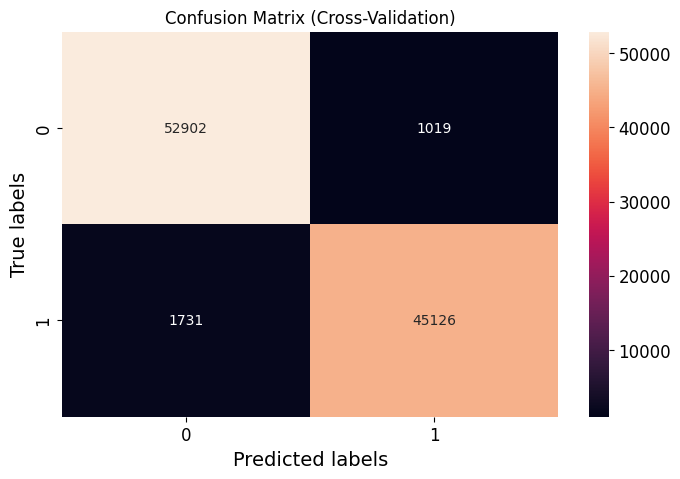

In [ ]:
logistic_regression_final = LogisticRegression(solver = best_solver, penalty=best_penalty, C=best_C, random_state = 42)
run_cross_val_with_cm(logistic_regression_final, selector_lasso, X_train, y_train)

### Random Forest
 Prima verifico come si comporta il modello senza alcun tipo di regolazione di parametri, quindi con i parametri di default:
 * **n_estimators**: numero di alberi decisionali nella foresta; \
 int, default=100
 * **criterion**: funzione per misurare la bontà di una split;\
 default='gini' ('log_loss' ed 'entropoy' per la minimizz. dell'IG)
 * **max_depth**: massima profondità degli alberi, se settata a 'None' le split dei nodi continuano fino a quando tutte le foglie contengono samples appartenenti alla stessa classe o fino a quando contengono meno di min_samples_split samples; \
 int, deafult='None'
 * **min_samples_split**: numero minimo di samples con $A^*=a$ (dove $A$ attributo scelto per la split, $a$ valore che può assumere) affinchè sia possibile fare la split (prepruning); \
 int or float, default=2
 * **min_samples_leaf**: numero minimo di samples che una foglia dell'albero deve avere, se specificato con un intero è il minimo, con un float è una frazione. \
 int or float, deafult=1
 * **max_features**: il numero di features da considerare in una split (per decorrelare gli alberi).\
 int, float, 'sqrt', 'log2'

      accuracy  precision    recall        f1
fold                                         
1     0.996874   0.998607  0.994664  0.996632
2     0.997817   0.998930  0.996372  0.997650
3     0.997470   0.998289  0.996265  0.997276
4     0.997668   0.998396  0.996585  0.997490
5     0.996973   0.996904  0.996585  0.996745
Mean  0.997361   0.998226  0.996094  0.997159


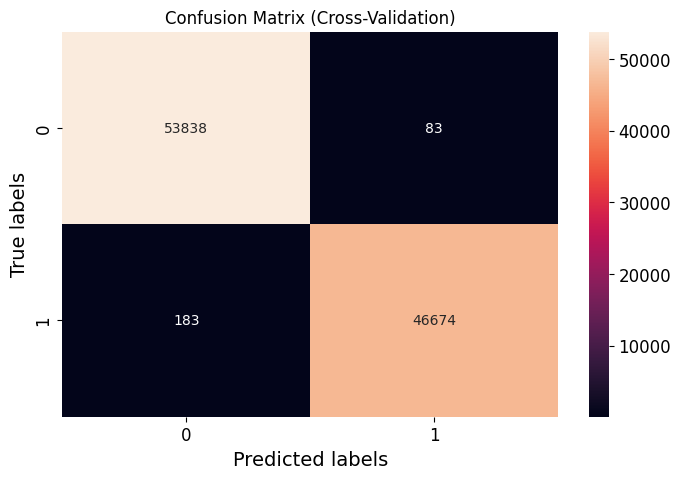

In [ ]:
random_forest = RandomForestClassifier(random_state = 42)
run_cross_val_with_cm(random_forest, selector_lasso, X_train, y_train)

Per regolare i parametri utilizzo RandomizedSearchCV, al contrario di GridSearchCV non proverà tutte le combinazioni di parametri ma selezionerà 'n_iter' combinazioni di valori contenuti nel campo 'param_distributions'. \
Potrebbe non trovare la combinazione ottima di parametri ma la computazione risulterà più veloce.

In [ ]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
param_distribution ={'classifier__n_estimators':randint(10,500),
                     'classifier__criterion':['gini', 'entropy', 'log_loss'],
                     'classifier__max_depth':randint(5,50),
                     'classifier__min_samples_split':uniform(0.01,0.3),
                     'classifier__min_samples_leaf':uniform(0.01,0.2),
                     'classifier__max_features':['sqrt', 'log2']
}
rfc = RandomForestClassifier(random_state = 42)
pipeline= make_pipeline(rfc, selector_lasso, num_columns, binary_columns, cat_columns)
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs= RandomizedSearchCV(pipeline,
                       param_distributions=param_distribution,
                       n_iter=20, scoring='recall',
                       cv=cv,
                       refit=True,
                       n_jobs=-1,
                       verbose=3,
                       random_state=42)
rs.fit(X_train, y_train)

best_n_estimators = rs.best_params_['classifier__n_estimators']
best_criterion = rs.best_params_['classifier__criterion']
best_max_depth = rs.best_params_['classifier__max_depth']
best_min_samples_split = rs.best_params_['classifier__min_samples_split']
best_min_samples_leaf = rs.best_params_['classifier__min_samples_leaf']
best_max_features = rs.best_params_['classifier__max_features']
print(rs.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'classifier__criterion': 'log_loss', 'classifier__max_depth': 49, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 0.013127281348238786, 'classifier__min_samples_split': 0.1370204442119109, 'classifier__n_estimators': 138}


Performance del modello con i parametri trovati da RandomizedSearchCV:

      accuracy  precision    recall        f1
fold                                         
1     0.947311   0.966955  0.918045  0.941866
2     0.959764   0.968275  0.944409  0.956193
3     0.952421   0.962609  0.933952  0.948064
4     0.956239   0.972504  0.932238  0.951945
5     0.956289   0.968026  0.936933  0.952226
Mean  0.954405   0.967674  0.933115  0.950059


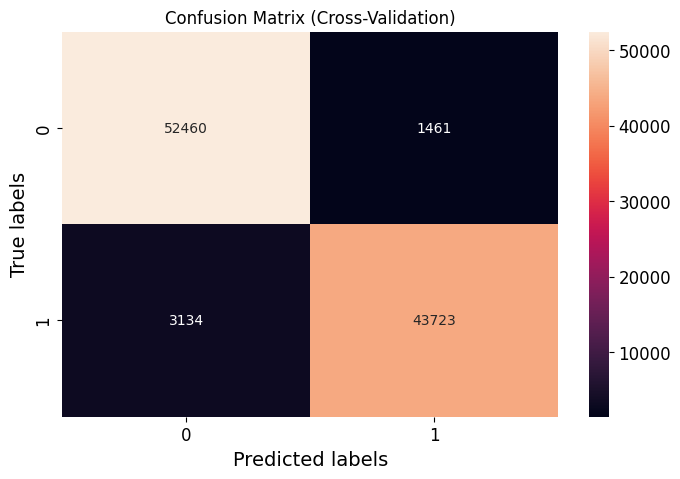

In [ ]:
random_forest_final = RandomForestClassifier(criterion=best_criterion,
                                       min_samples_split=best_min_samples_split,
                                       class_weight= None,
                                       max_features=best_max_features,
                                       min_samples_leaf=best_min_samples_leaf,
                                       max_depth=best_max_depth,
                                       n_estimators=best_n_estimators,
                                       random_state = 42)
run_cross_val_with_cm(random_forest_final, selector_lasso, X_train, y_train)

Dopo il tuning il modello sembra peggiorare, questo dipende dal fatto che senza tuning la random forest con i parametri di default si adattava troppo bene ai dati soffrendo quindi di overfitting.






### MLP

Per definire una rete neurale uso l'MLP Classifier definito in scikit learn.\
 Per cominciare vedo come si comporta il modello senza alcun tuning, come funzione di attivazione del livello nascosto scelgo la tangente iperbolica, dato che empiricamente dimostrato essere la migliore per la classificazione binaria. Come ottimizzatore utilizzo 'adaptive moments' (Adam), per cui andranno regolati gli iperparametri $β_1$ e $β_2$. \
 Infine utilizzo l'early stopping, in questo caso il parametro max_iter indicherà il massimo numero di epoche.

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='tanh', solver='adam', early_stopping= True, max_iter=200, random_state = 42)
run_cross_val(mlp, selector_lasso, X_train, y_train)

      accuracy  precision    recall        f1
fold                                         
1     0.988539   0.984932  0.990503  0.987709
2     0.990325   0.991327  0.987836  0.989578
3     0.989184   0.992468  0.984208  0.988321
4     0.990127   0.986837  0.991997  0.989410
5     0.987695   0.979199  0.994664  0.986871
Mean  0.989174   0.986953  0.989842  0.988378


Senza alcun tipo di tuning già si ottiene un ottimo risultato su tutte le metriche, che però può sicuramente essere migliorato provando diverse combinazioni di parametri, utilizzando sempre RandomizedSearchCV:
* **hidden_layer_sizes**: definisce la struttura dei livelli nascosti della rete, proverò al massimo una configurazione con due livelli nascosti.
* **alpha**: definisce l'impatto della L2 regolarization function sui pesi della rete
* **learning_rate_init**: valore a cui viene inizializzato il learning rate
* **beta_1**: il friction parameter per il primo momento in Adam, definisce l'influenza dello 'slancio' dato dal momento
* **beta_2**: definisce l'importanza del momento del secondo gradiente (cioè dell'ampiezza degli aggiornamenti dei pesi)


Provo a regolare anche i parametri dell'early sopping modificando:
* **n_iter_no_change**: la *patience*, cioè il numero di volte in cui l'algoritmo non vede un miglioramento di almeno il valore di 'tol' prima di fermarsi
* **tol**: la tolleranza, se lo score della loss function non migliora almeno di questo valore per 'n_iter_no_change' l'algoritmo si ferma


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
mlp = MLPClassifier(activation='tanh', solver='adam', early_stopping= True, validation_fraction=0.2, max_iter=500, random_state = 42)
pipeline= make_pipeline(mlp, selector_lasso, num_columns, binary_columns, cat_columns)
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_distribution={
    'classifier__hidden_layer_sizes': [(16,), (32,), (64,), (128,), (256,), (16,32,), (32,32,), (32,64)],
    'classifier__alpha':  np.logspace(-5, 2, 10), #[0.0001, 0.001, 0.01],
    'classifier__learning_rate_init':[1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'classifier__beta_1': [0.85,0.9,0.95,0.99],
    'classifier__beta_2':[0.99, 0.999],
    'classifier__n_iter_no_change': [10,15,20],
    'classifier__tol': [1e-3, 1e-4, 1e-5]
}

rs= RandomizedSearchCV(pipeline,
                       param_distributions=param_distribution,
                       n_iter=20,
                       scoring='recall',
                       cv=cv,
                       refit=True,
                       n_jobs=-1,
                       verbose=3,
                       random_state=42,
                       return_train_score=True,
                       error_score="raise")

rs.fit(X_train, y_train)

print("Best parameters:", rs.best_params_)
print("Best score:", rs.best_score_)

best_params_mlp= rs.best_params_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'classifier__tol': 0.0001, 'classifier__n_iter_no_change': 20, 'classifier__learning_rate_init': 0.0001, 'classifier__hidden_layer_sizes': (64,), 'classifier__beta_2': 0.99, 'classifier__beta_1': 0.95, 'classifier__alpha': 5.994842503189409e-05}
Best score: 0.9944298396452254


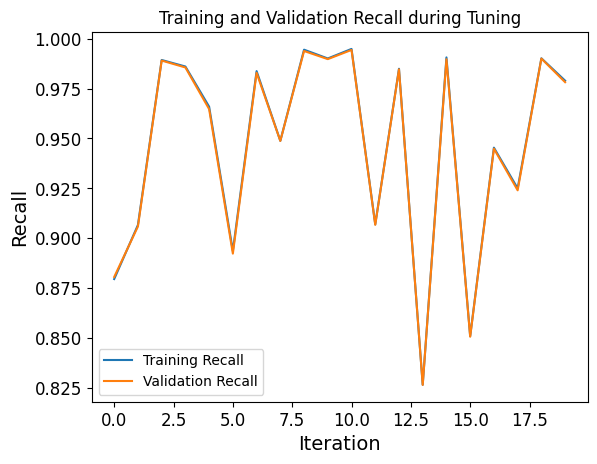

In [ ]:
# per vedere gli score della recall durante le iterazioni di RandomizedSearchCV su train e validation fold
train_scores = rs.cv_results_['mean_train_score']
validation_scores = rs.cv_results_['mean_test_score']

plt.plot(train_scores, label='Training Recall')
plt.plot(validation_scores, label='Validation Recall')
plt.xlabel('Iteration')
plt.ylabel('Recall')
plt.title('Training and Validation Recall during Tuning')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


      accuracy  precision    recall        f1
fold                                         
1     0.993848   0.994651  0.992103  0.993375
2     0.995684   0.994778  0.995945  0.995361
3     0.995188   0.995301  0.994345  0.994823
4     0.995535   0.995621  0.994771  0.995196
5     0.995783   0.995306  0.995625  0.995465
Mean  0.995207   0.995131  0.994558  0.994844


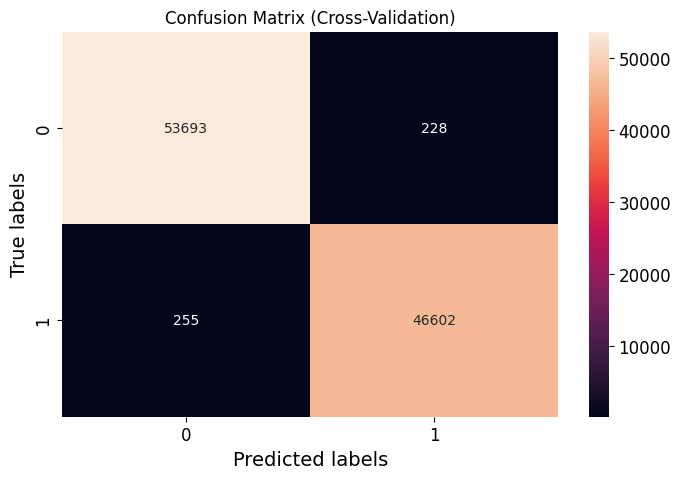

In [ ]:
mlp_final = MLPClassifier(hidden_layer_sizes= best_params_mlp['classifier__hidden_layer_sizes'],
                    activation='tanh',
                    solver='adam',
                    early_stopping= True,
                    learning_rate_init =  best_params_mlp['classifier__learning_rate_init'],
                    alpha= best_params_mlp['classifier__alpha'],
                    beta_1 =best_params_mlp['classifier__beta_1'],
                    beta_2=best_params_mlp['classifier__beta_2'],
                    n_iter_no_change=best_params_mlp['classifier__n_iter_no_change'],
                    tol=best_params_mlp['classifier__tol'],
                    random_state = 42)
run_cross_val_with_cm(mlp_final, selector_lasso, X_train, y_train)

### Adaboost
Algoritmo  che usa un ensamble di weak learner, l'i-esimo weak learner viene addestrato modificando i pesi dei samples in modo che si concentri sugli esempi classificati erronemente dai classificatori precedenti.

Di deafult AdaBoostClassifier() utilizza come weak learner degli alberi decisionali di altezza 1.

Altri parametri sono:
* **n_estimators**: massimo numero di weak learner, in caso di perfect fit l'algoritmo si fermerà prima
* **learning rate**: peso applicato ad ogni classificatore, determina l'influenza dei weak learner nel classificatore finale.

      accuracy  precision    recall        f1
fold                                         
1     0.961004   0.972899  0.942375  0.957394
2     0.965321   0.971820  0.953052  0.962344
3     0.962344   0.967133  0.951344  0.959174
4     0.972017   0.975900  0.963611  0.969716
5     0.960853   0.969989  0.945043  0.957354
Mean  0.964308   0.971548  0.951085  0.961196


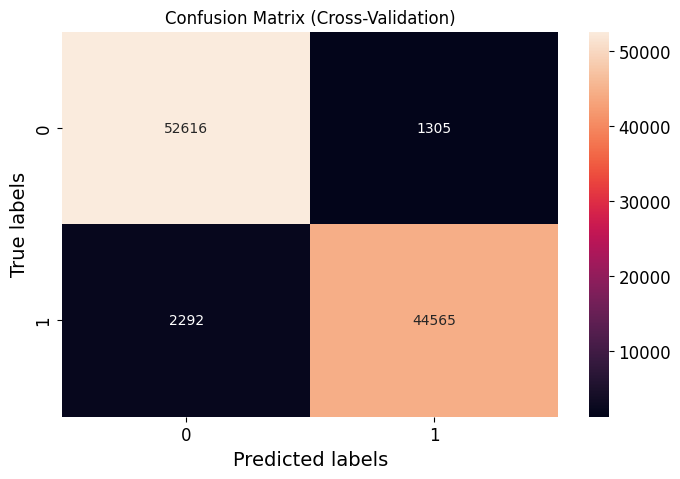

In [ ]:
adaboost_clf = AdaBoostClassifier(
    random_state=42)
run_cross_val_with_cm(adaboost_clf, selector_lasso, X_train, y_train)

Provo ora differenti combinazioni tra numero di weak learner e learning rate utilizzando GridSearchCV.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'classifier__n_estimators' : [10, 50, 100, 200],
    'classifier__learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1.0],
}
adaboost_clf = AdaBoostClassifier(random_state=42)
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline=make_pipeline(adaboost_clf, selector_lasso, num_columns, binary_columns, cat_columns)
gs = GridSearchCV(pipeline,
                        param_grid=param_grid,
                        scoring='recall',
                        cv=cv,
                        refit=True,
                        n_jobs=-1,
                        verbose=2)
gs.fit(X_train, y_train)
best_params_ada=gs.best_params_
print(best_params_ada)
print("migliore recall con questi parametri:", gs.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'classifier__learning_rate': 1.0, 'classifier__n_estimators': 200}
migliore recall con questi parametri: 0.9760760841114374


Performance del tuned AdaBoost classifier:

      accuracy  precision    recall        f1
fold                                         
1     0.980403   0.985399  0.972255  0.978783
2     0.983380   0.984662  0.979513  0.982081
3     0.980800   0.983013  0.975566  0.979275
4     0.981890   0.985551  0.975349  0.980424
5     0.981940   0.983364  0.977697  0.980522
Mean  0.981683   0.984398  0.976076  0.980217


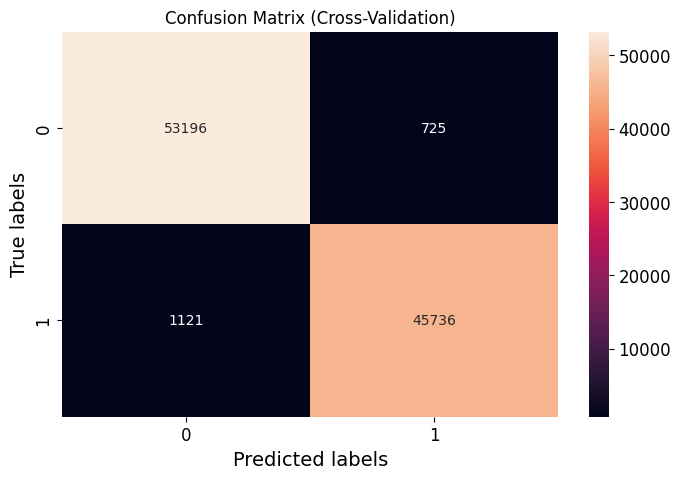

In [ ]:
adaboost_clf_final = AdaBoostClassifier(
    learning_rate= best_params_ada[ 'classifier__learning_rate'],
    n_estimators=best_params_ada['classifier__n_estimators'],
    random_state=42)
run_cross_val_with_cm(adaboost_clf_final, selector_lasso, X_train, y_train)

## Confronto tra i modelli
In questa parte, dopo aver effettuato il tuning dei 4 classificatori, ne vengono analizzate le prestazioni sul test set per determinare quale sia il migliore.

Prima di tutto faccio diventare la classe target del test set binaria e la divido poi dal resto del test set.

In [ ]:
y_test = test_set['label'].apply(lambda x: 0 if x == 'normal' else 1)
X_test = test_set.drop('label', axis=1)
X_test.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
378,0,udp,domain_u,SF,36,0,0,0,0,0,...,67,171,1.00,0.00,1.00,0.01,0.00,0.0,0.00,0.0
32038,0,tcp,http,S0,0,0,0,0,0,0,...,255,44,0.17,0.05,0.01,0.00,1.00,1.0,0.00,0.0
86399,0,tcp,pop_3,S0,0,0,0,0,0,0,...,255,20,0.08,0.06,0.00,0.00,1.00,1.0,0.00,0.0
74412,0,tcp,private,REJ,0,0,0,0,0,0,...,255,27,0.11,0.07,0.00,0.00,0.00,0.0,1.00,1.0
52951,0,tcp,private,RSTR,0,0,0,0,0,0,...,134,1,0.01,0.64,0.64,0.00,0.04,0.0,0.63,1.0


Unisco in un dizionario tutti i classificatori trovati nella sezione precedente e li stampo

In [ ]:
classifiers = {
    "Logistic Regression": logistic_regression_final,
    "Random Forest": random_forest_final,
    "MLP": mlp_final,
    "AdaBoost": adaboost_clf_final
}
print("final logistic regression:\n", logistic_regression_final)
print("final random forest:\n", random_forest_final)
print("final multi-layer perceptron:\n", mlp_final)
print("final adaboost classifier:\n",adaboost_clf_final)

final logistic regression:
 LogisticRegression(C=1, penalty='l1', random_state=42, solver='liblinear')
final random forest:
 RandomForestClassifier(criterion='log_loss', max_depth=49,
                       min_samples_leaf=0.013127281348238786,
                       min_samples_split=0.1370204442119109, n_estimators=138,
                       random_state=42)
final multi-layer perceptron:
 MLPClassifier(activation='tanh', alpha=5.994842503189409e-05, beta_1=0.95,
              beta_2=0.99, early_stopping=True, hidden_layer_sizes=(64,),
              learning_rate_init=0.0001, n_iter_no_change=20, random_state=42)
final adaboost classifier:
 AdaBoostClassifier(n_estimators=200, random_state=42)


Ora per ogni classificatore nel dizionario uso 'make_pipeline' per creare la pipeline contenente il pre-processamento, la feature selection e il classificatore specificato in 'clf'. Chiamo il metodo 'fit' sul training set e labels in modo da addestrare ogni componente della pipeline, poi il metodo 'predict' sul test set per ottenere le predizioni effettuate dal classificatore addestrato.  

In [ ]:
results = {}

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(clf, selector_lasso, num_columns, binary_columns, cat_columns)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[clf_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

for clf_name, metrics in results.items():
    print(f"--- {clf_name} ---")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")
    print("\n")

--- Logistic Regression ---
Accuracy: 0.9703
Precision: 0.9761
Recall: 0.9599
F1-Score: 0.9679


--- Random Forest ---
Accuracy: 0.9539
Precision: 0.9682
Recall: 0.9320
F1-Score: 0.9498


--- MLP ---
Accuracy: 0.9947
Precision: 0.9949
Recall: 0.9938
F1-Score: 0.9943


--- AdaBoost ---
Accuracy: 0.9801
Precision: 0.9830
Recall: 0.9742
F1-Score: 0.9786




Visualizzo i risultati delle quattro metriche per tutti i classificatori

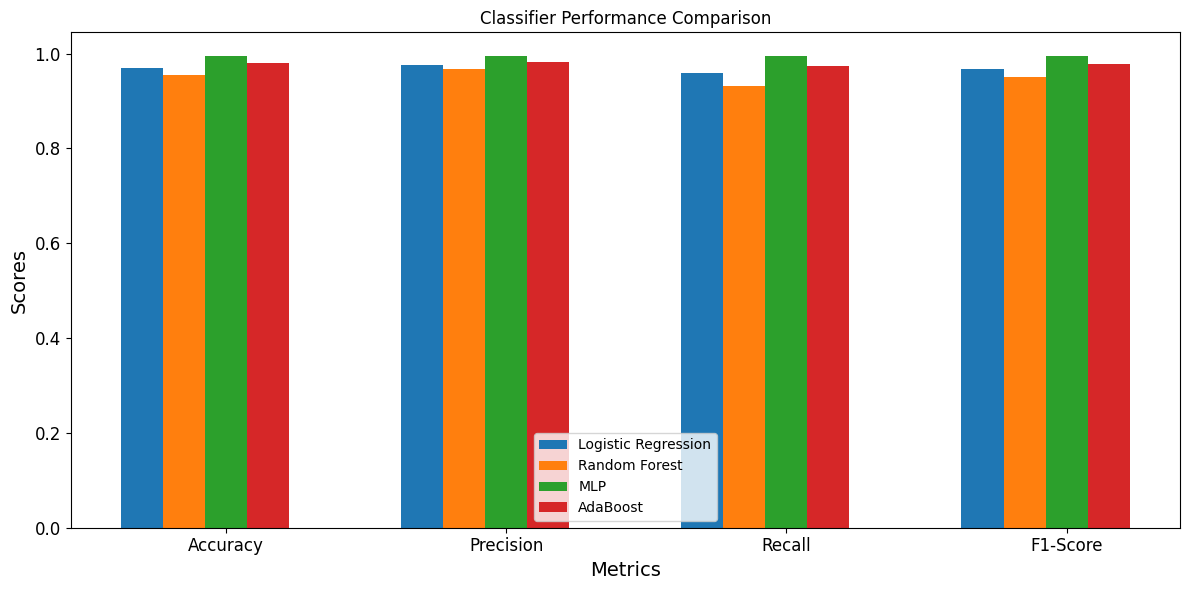

In [ ]:

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
clf_names = list(results.keys())
num_metrics = len(metrics)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.15
index = np.arange(num_metrics)

for i, clf_name in enumerate(clf_names):
    values = [results[clf_name][metric] for metric in metrics]
    ax.bar(index + i * bar_width, values, bar_width, label=clf_name)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(index + bar_width * (len(clf_names) / 2))
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

## Conclusioni
Come si evince dal grafico finale il modello che performa meglio è il multi-layer perceptron, avendo tutte e 4 le metriche a più del 99%, in particolare l'MLP in esame ottiene una recall del $99.38$% e una precision del $99.49$%.

Questo dimostra la capacità della rete neurale di identificare correttamente i casi positivi, minimizzando i falsi negativi e i falsi positivi. Garantisce quindi che la quasi totalità del traffico predetto come 'malevolo' sia effettivamente etichettato come tale e che la quasi totalità del traffico etichettato come 'malevolo' venga riconosciuto come tale.

Il classificatore con il risultato peggiore è la random forest, questa performance non ottima è data dall'approccio di feature selection scelto che suppone una relazione lineare tra le feature e la classe target.
Inoltre penso dipenda anche dalla natura sparsa del dataset NSL-KDD, infatti questo porta gli alberi ad avere split meno informative dato che sono composte per la maggior parte da zero.